# Grammy Awards Website Engagement Analysis


In February 2022, The Recording Academy made the decsion to split its digital presence into two separate websites, grammy.com and recordingacademy.com, to better target specific audiences. 

This project analyzes website traffic, engagement, demographic, and device data to evaluate the impact of the split and creates a data-driven business reccomendation to improve the user experience of each website.

The analysis focuses on:

- website traffic and the impact of Grammy Awards nights
- pages viewed per session
- bounce rate
- average session duration
- audience demographics
- desktop vs. mobile behavior
- competitive performance against the American Music Awards (AMA)

## Business Objective

**How has separating grammy.com and recordingacademy.com affected user engagement, and should The Recording Academy keep operating the websites separately?**


## Dataset & Metrics
The data used for this analysis (located under the data/ directory) covers grammy.com and recordingacademy.com's audience demographics and device traffic:

- `grammys_live_web_analytics.csv` : full dataset of the grammy.com website engagement from 2017 to 2023. This includes engagement records before and after the website split. 

- `ra_live_web_analytics.csv`: full dataset of the recordingacademy.com website engagement from 2022-2023, post website split 

Key fields include:

- **date** - The date the data was confirmed. It is in `yyyy-mm-dd` format.
- **visitors** - The number of users who went on the website on that day.
- **pageviews** - The number of pages that all users viewed on the website.
- **sessions** - The total number of sessions on the website. A session is a group of user interactions with a website that take place within a given time frame. For example a single session can contain multiple page views, events, social interactions, etc.
- **bounced_sessions** - The total number of bounced sessions on the website. A bounced session happens when a visitor comes to the website and does not interact with any pages / links and leaves.
- **avg_session_duration_secs** - The average length for all session durations for all users that came to the website that day.
- **awards_week** - A binary flag if the dates align with marketing campaigns before and after the Grammys award ceremony was held.
- **awards_night** - The actual night that Grammy Awards event was held.

Three Key Performance Indicators (KPIs) will be evaluated:
1. **Pages per Session** - how many pages users will view during a session
2. **Bounce Rate** - percentage of sessions that end without further interaction
3. **Average Session Duration** - how long users spend on the website

# 1. Setup and Data Loading

Read in the needed csv files, preview the data, and check for any missing or dupicate values


In [1]:
# Import libraries
import pandas as pd
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "png"

In [2]:
# Read in dataframes
full_df = pd.read_csv("../data/grammy_live_web_analytics.csv", parse_dates=["date"])
rec_academy = pd.read_csv("../data/ra_live_web_analytics.csv", parse_dates=["date"])

print(
    f"Grammy historical dataset: "
    f"{full_df.shape[0]:,} rows x {full_df.shape[1]} columns"
)

print(
    f"Recording Academy dataset: "
    f"{rec_academy.shape[0]:,} rows x {rec_academy.shape[1]} columns"
)

Grammy historical dataset: 2,342 rows x 8 columns
Recording Academy dataset: 485 rows x 8 columns


In [3]:
# Preview data
display(full_df.head())
display(rec_academy.head())

# Basic data-quality checks.
quality_checks = pd.DataFrame({
    "Dataset": [
        "Grammy historical data",
        "Recording Academy data"
    ],
    "Duplicate rows": [
        full_df.duplicated().sum(),
        rec_academy.duplicated().sum()
    ],
    "Missing values": [
        full_df.isna().sum().sum(),
        rec_academy.isna().sum().sum()
    ]
})

quality_checks

,date,visitors,pageviews,sessions,bounced_sessions,avg_session_duration_secs,awards_week,awards_night
0,2017-01-01,9611,21407,10196,6490,86,0,0
1,2017-01-02,10752,25658,11350,7055,100,0,0
2,2017-01-03,11425,27062,12215,7569,92,0,0
3,2017-01-04,13098,29189,13852,8929,90,0,0
4,2017-01-05,12234,28288,12990,8105,95,0,0


,date,visitors,pageviews,sessions,bounced_sessions,avg_session_duration_secs,awards_week,awards_night
0,2022-02-01,928,2856,1092,591,148,0,0
1,2022-02-02,1329,3233,1490,923,90,0,0
2,2022-02-03,1138,3340,1322,754,127,0,0
3,2022-02-04,811,2552,963,534,142,0,0
4,2022-02-05,541,1530,602,326,111,0,0


,Dataset,Duplicate rows,Missing values
0,Grammy historical data,0,0
1,Recording Academy data,0,0


## 2. Website Traffic and Awards Night Impact

Before evaluating the website split, it is useful to understand how visitor traffic of the website behaves over time, and take into account the impact of the annual awards ceremony

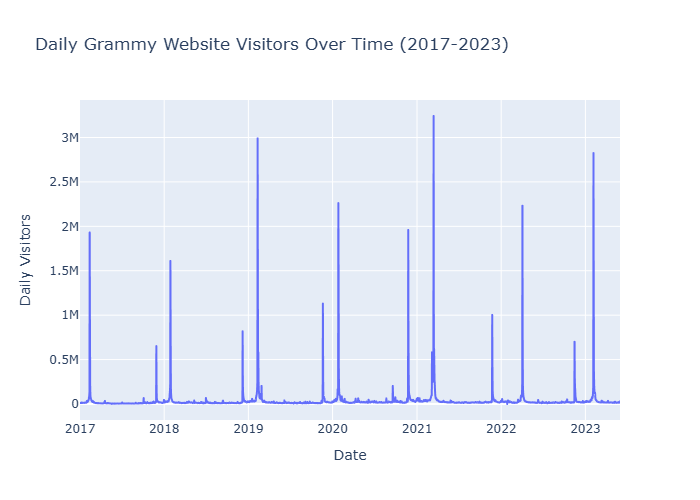

In [4]:
# line chart of the visitors on the site.
fig = px.line(
    full_df,
    x='date',
    y='visitors',
    title="Daily Grammy Website Visitors Over Time (2017-2023)",
    labels={
        "date": "Date",
        "visitors": "Daily Visitors"
    }
    )
fig.update_layout(hovermode="x unified") # make a single tooltip display all datapoints

fig.show()

### Traffic Pattern

High traffic spikes occur every year between January and April, aligning with the timing of the Grammy Awards ceremony. However, smaller traffic spikes that occur during other parts of the awards cycle could possibly correspond to lesser-known events such as the announcement of Grammy nominations, which can create additional traffic outside of the ceremony itself.

In [5]:
# Compare average traffic on awards nights with all other days

# Average number of visitors on awards nights versus other nights
awards_night_traffic = full_df.groupby('awards_night', as_index=False).agg({'visitors' : 'mean'})

awards_night_traffic["day_type"] = (
    awards_night_traffic["awards_night"]
    .map({
        0: "Regular Day",
        1: "Awards Night"
    })
)

awards_night_traffic[["day_type", "visitors"]]


,day_type,visitors
0,Regular Day,3.238828e+04
1,Awards Night,1.389590e+06


In [6]:
regular_day_avg = awards_night_traffic.loc[
    awards_night_traffic["awards_night"] == 0,
    "visitors"
].iloc[0]

awards_night_avg = awards_night_traffic.loc[
    awards_night_traffic["awards_night"] == 1,
    "visitors"
].iloc[0]

traffic_multiplier = awards_night_avg / regular_day_avg

print(
    f"Average visitors on regular days: "
    f"{regular_day_avg:,.0f}"
)

print(
    f"Average visitors on awards nights: "
    f"{awards_night_avg:,.0f}"
)

print(
    f"Awards-night traffic multiplier: "
    f"{traffic_multiplier:.1f}x"
)

Average visitors on regular days: 32,388
Average visitors on awards nights: 1,389,590
Awards-night traffic multiplier: 42.9x


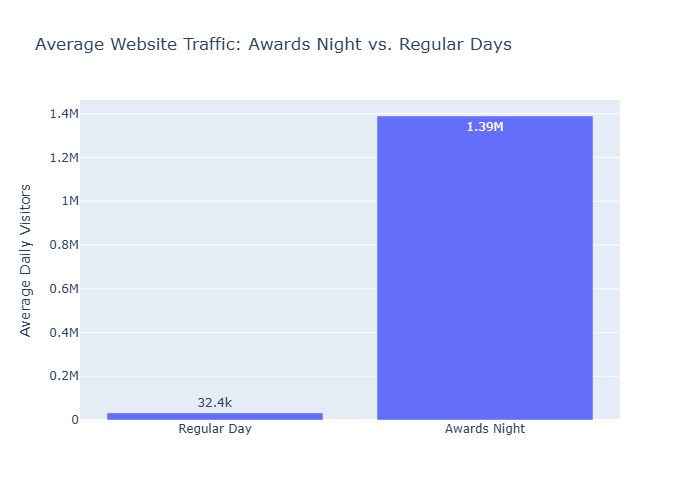

In [7]:
fig = px.bar(
    awards_night_traffic,
    x="day_type",
    y="visitors",
    text_auto=".3s",
    title="Average Website Traffic: Awards Night vs. Regular Days",
    labels={
        "day_type": "",
        "visitors": "Average Daily Visitors"
    }
)

fig.show()

This comparison reveals that the site has significantly more visitors on awards nights. On average, a night with an awards show has almost 43 times more visitors than a night without. This finding raises an important question: how might The Recording Academy convert this small, annual engagement boost into sustained, year-round engagement?

## 3. Evaluating the 2022 website split

As mentioned previously, when The Recording Academy split its digital presence across two domains, grammy.com and recordingacademy.com, the data capture for grammy.com was not affected. This means that the way visitor data was collected for grammy.com stayed exactly the same before and after the split. With that in mind, the data from before the split (when both sites were combined) and after the split (when grammy.com data continued independently) must be separated to conduct a proper analysis.

The split happened on February 1, 2022 (`2022-02-01`), so the historical Grammy dataset will be divided into:

- **Combined Site** - activity before February 1, 2022
- **Grammy.com** - activity on or after February 1, 2022
- **RecordingAcademy.com** - activity from the separate Recording Academy dataset

In [8]:
# Split the data to separate the full_df into two new dataframes.
# One for before the switch of the websites and one for after

combined_site = full_df[full_df['date'] < '2022-02-01'].copy()
grammys = full_df[full_df['date'] >= '2022-02-01'].copy()

sites = {
    "Combined Site" : combined_site,
    "Grammy.com" : grammys,
    "RecordingAcademy.com" : rec_academy
}

for name, frame in sites.items():
    print(f"{name}: {len(frame):,} rows")

Combined Site: 1,857 rows
Grammy.com: 485 rows
RecordingAcademy.com: 485 rows


### Pages per Session

The pages per session metric measures how many pages a user views during an average session. Higher values indicate that visitors are exploring more content and are generally more engaged with the website.

In [9]:
for frame in sites.values():
    frame['pages_per_session'] = frame['pageviews'] / frame['sessions']

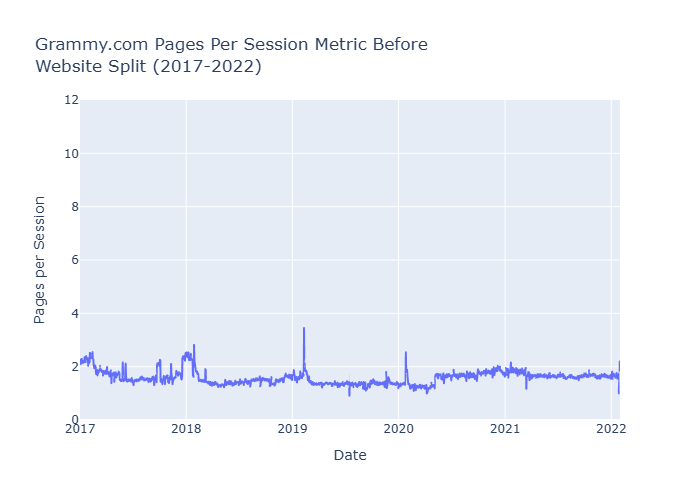

In [10]:
# combined_site graph
fig = px.line(
    combined_site,
    x='date',
    y='pages_per_session',
    title="Grammy.com Pages Per Session Metric Before <br>Website Split (2017-2022)",
    labels={
        "pages_per_session" : "Pages per Session",
        "date" : "Date"
    }
    )
fig.update_yaxes(range=[0,12])
fig.update_layout(hovermode="x unified")

fig.show()

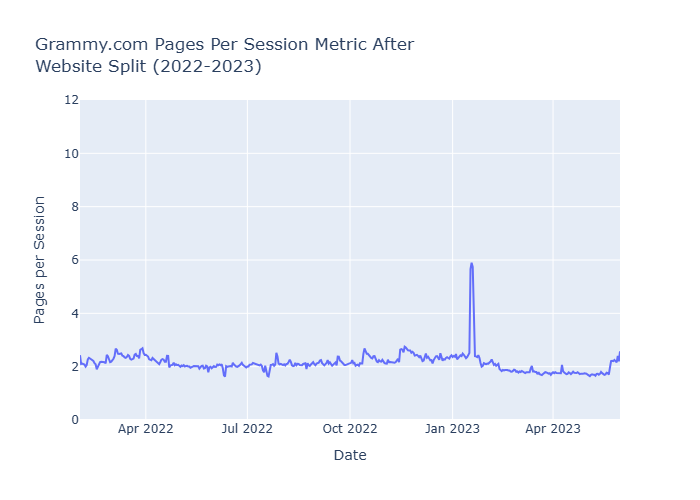

In [11]:
# grammys graph
fig = px.line(
    grammys,
    x='date',
    y='pages_per_session',
    title="Grammy.com Pages Per Session Metric After <br>Website Split (2022-2023)",
    labels={
        "pages_per_session" : "Pages per Session",
        "date" : "Date"
    }
    )
fig.update_yaxes(range=[0,12])
fig.update_layout(hovermode="x unified")

fig.show()

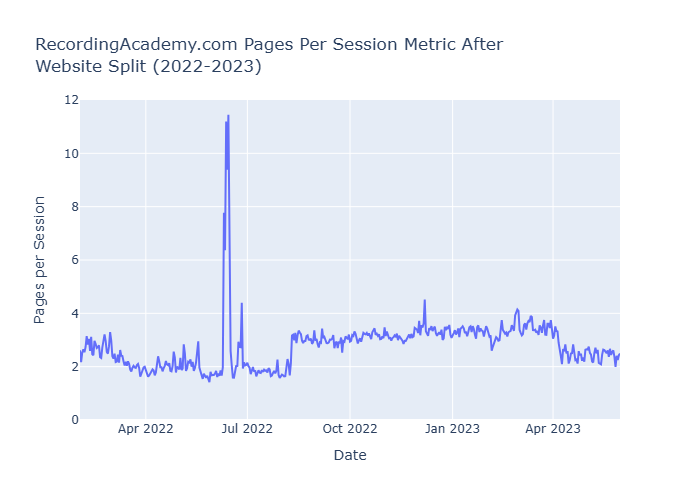

In [12]:
# rec_academy graph
fig = px.line(
    rec_academy,
    x='date',
    y='pages_per_session',
    title="RecordingAcademy.com Pages Per Session Metric After <br>Website Split (2022-2023)",
    labels={
        "pages_per_session" : "Pages per Session",
        "date" : "Date"
    }
    )
fig.update_yaxes(range=[0,12])
fig.update_layout(hovermode="x unified")

fig.show()

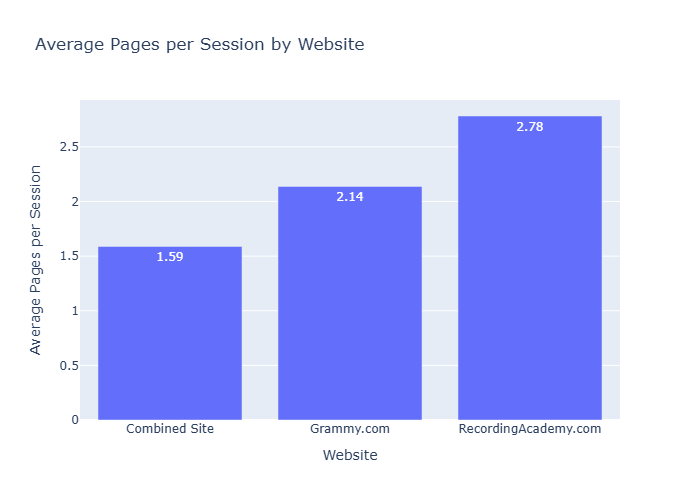

In [22]:
pages_per_session = pd.DataFrame({
    "Website": sites.keys(),
    "Avg. Pages per Session": [
        frame["pages_per_session"].mean()
        for frame in sites.values()
    ]
})

pages_per_session.round(2)

fig = px.bar(
    pages_per_session,
    x="Website",
    y="Avg. Pages per Session",
    text_auto=".2f",
    title="Average Pages per Session by Website",
    labels={
        "Avg. Pages per Session":
        "Average Pages per Session"
    }
)

fig.show()

The analysis shows that pages per session slightly increased for grammys.com and substantially increased on recordingacademy.com after the split. This suggests that the more focused Recording Academy website encoraged deeper content exploration and user engagement. 

### Bounce Rate
Bounce rate measures the percentage of sessions in which visitors leave without further interaction. A lower bounce rate indicates stronger initial engagement

In [14]:
def bounce_rate(dataframe):
    '''
    Calculates the bounce rate for visitors on the website.
    input: dataframe with bounced_sessions and sessions columns
    output: numeric value from bounce rate
    '''
    
    sum_bounced = dataframe['bounced_sessions'].sum()
    sum_sessions = dataframe['sessions'].sum()
    
    return 100 * (sum_bounced / sum_sessions)


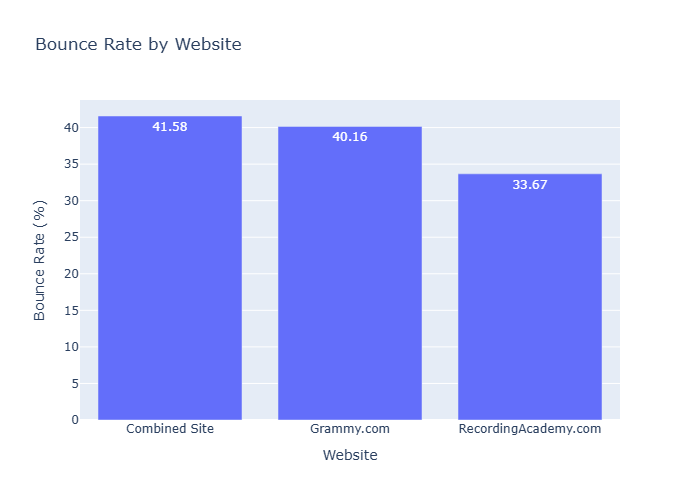

In [23]:
# Calculate the Bounce Rate for each site

bounce_rates = pd.DataFrame({
    "Website": sites.keys(),
    "Bounce Rate (%)": [
        bounce_rate(frame)
        for frame in sites.values()
    ]
})

bounce_rates.round(2)

fig = px.bar(
    bounce_rates,
    x="Website",
    y="Bounce Rate (%)",
    text_auto=".2f",
    title="Bounce Rate by Website",
    labels={
        "Bounce Rate (%)":
        "Bounce Rate (%)"
    }
)

fig.show()

The analysis produced the following bounce rates:

- **Combined Site:** 41.58%
- **Grammy.com:** 40.16%
- **RecordingAcademy.com:** 33.67%

RecordingAcademy.com shows the strongest improvement, while Grammy.com's bounce rate remains relatively close to the pre-split combined site.

### Average Session Duration

Average session duration provides another view of engagement by measuring how long visitors remain on each website

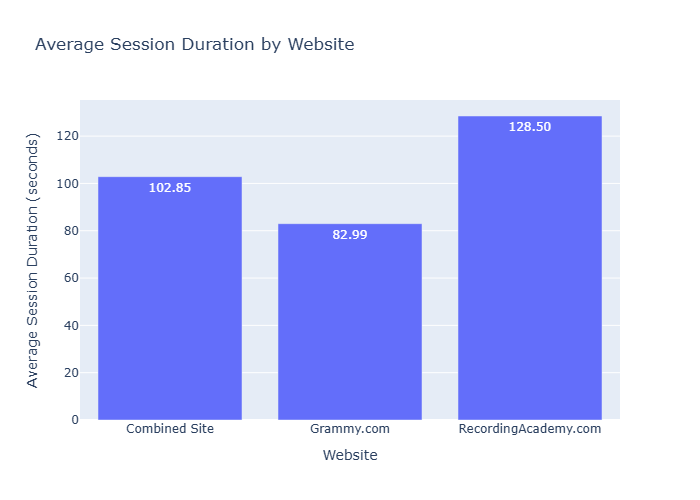

In [24]:
session_duration = pd.DataFrame({
    "Website": sites.keys(),
    "Avg. Session Duration (sec)": [
        frame["avg_session_duration_secs"].mean()
        for frame in sites.values()
    ]
})

session_duration.round(2)

fig = px.bar(
    session_duration,
    x="Website",
    y="Avg. Session Duration (sec)",
    text_auto=".2f",
    title="Average Session Duration by Website",
    labels={
        "Avg. Session Duration (sec)":
        "Average Session Duration (seconds)"
    }
)

fig.show()

The analysis found:

- **Combined Site:** 102.85 seconds
- **Grammy.com:** 82.99 seconds
- **RecordingAcademy.com:** 128.50 seconds

RecordingAcademy.com increased average session duration by roughly 26 seconds relative
to the old combined site.

Grammy.com, by contrast, decreased by roughly 20 seconds.

### Engagement Summary

The three KPIs can be organized into a single table for a concise view of website performance:

In [17]:
engagement_summary = pd.DataFrame({
    "Website": sites.keys(),

    "Avg. Pages per Session": [
        frame["pages_per_session"].mean()
        for frame in sites.values()
    ],

    "Bounce Rate (%)": [
        bounce_rate(frame)
        for frame in sites.values()
    ],

    "Avg. Session Duration (sec)": [
        frame["avg_session_duration_secs"].mean()
        for frame in sites.values()
    ]
})

engagement_summary.round(2)

,Website,Avg. Pages per Session,Bounce Rate (%),Avg. Session Duration (sec)
0,Combined Site,1.59,41.58,102.85
1,Grammy.com,2.14,40.16,82.99
2,RecordingAcademy.com,2.78,33.67,128.50


### Engagement Findings

The effect of the split ultimately produced different outcomes for each of the websites. RecordingAcademy.com experienced the strongest improvement, seeing a boost in all three KPIs. Average time on sight saw an increase of 25.65 seconds from the combined site (128.5 - 102.85 = 25.65), bounce rate was reduced by 7.91% (33.67 - 41.58 = -7.91%), and average pages per session increased by 1.19 (2.78 - 1.59 = 1.19).  

In contrast, the grammys website produced more mixed results. While its bounce rate remained relatively stable at 40.16% (about -1.42% from the combined site) and pages per session increased slightly (by 0.55), average session duration declined to 82.99 seconds, a difference of 19.86 seconds from the combined site. 

These results suggest that the separation of the Recording Academy audience from the Grammy audience created a more engaging experience for RecordingAcademy.com users, but that decision also may have hurt some of grammy.com's engagement statistics. Although grammy.com continues to attract visitors, it should try to seek more opportunities to encourage deeper and longer user interaction to boost the average session duration metric.

# 4. Audience Demographics

Audience demographics will help evaluate whether the two websites actually serve meanigfully different visitor groups as intended. For this analysis, the files `grammys_age_demographics.csv` and `tra_age_demographics.csv` will be used. Each contains the following information:

- **age_group** - The age group range. e.g. `18-24` are all visitors between the ages of 18 to 24 who come to the site.
- **pct_visitors** - The percentage of all of the websites visitors that come from that specific age group.



In [18]:
# Read in the files
age_grammys = pd.read_csv("../data/grammys_age_demographics.csv")
age_tra = pd.read_csv("../data/tra_age_demographics.csv")

# Label rows as 'Grammys'
age_grammys['website'] = 'Grammys'

# Label rows as 'Recording Acadamey'
age_tra['website'] = 'Recording Academy'

# Concatenate dataframes to join two dataset together (stack on top of eachother)
age_df = pd.concat([age_grammys, age_tra], axis=0)

# Preview combined data
age_df

,age_group,pct_visitors,website
0,18-24,27.373210,Grammys
1,25-34,24.129273,Grammys
2,35-44,18.717867,Grammys
3,45-54,13.568619,Grammys
4,55-64,9.817036,Grammys
5,65+,6.393994,Grammys
0,18-24,27.116827,Recording Academy
1,25-34,26.155406,Recording Academy
2,35-44,19.548684,Recording Academy
3,45-54,13.823158,Recording Academy


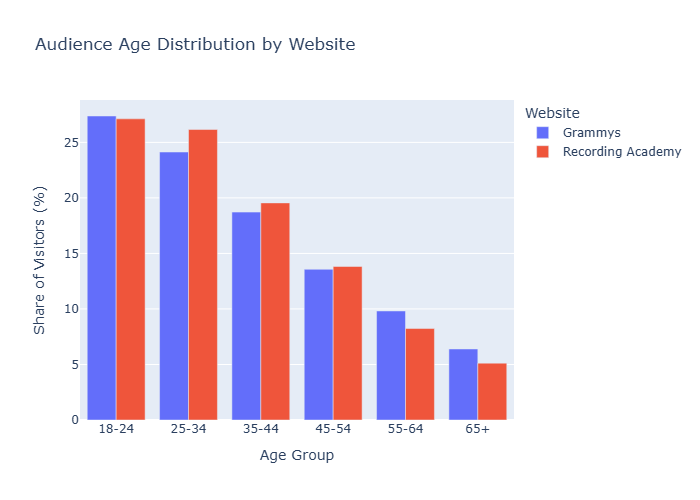

In [25]:
# age_group and pct_visitors bar chart
fig = px.bar(
    age_df,
    x="age_group",
    y="pct_visitors",
    color="website",
    barmode="group",
    title="Audience Age Distribution by Website",
    labels={
        "age_group": "Age Group",
        "pct_visitors": "Share of Visitors (%)",
        "website": "Website"
    }
)

fig.show()

Both websites seem to attract a more younger audience (individuals aged 18-34). However the Grammys website is skewed more towards a younger audience, while the Recording Academy website has a slightly greater representation amongst older age groups. This suggests that the grammys.com website attracts a more broad, entertainement-focused audience (who are more likely to be younger individuals), while the recording academy site attracts a more professional demographic, particularly more mid-aged individuals. These differences support the fact that the two websites serve different audiences and benefit from targeted digital experiences.  

## 5. Business Recommendation



**Following an analysis of engagement data before and after the 2022 separation of grammys.com and recordingacademy.com, the data suggests that keeping these sites separate is the most effective strategy to boost user engagement, with a few additional suggested improvements to further enhance performance on grammys.com.** 

The split had significantly improved engagement on recordingacademy.com. Metrics like pages per session increased, bounce rate declined by 8%, and average time on site went up by over 25 seconds. This indicated that users, mostly within the mid-aged demographic, are finding the content they enjoy and are interacting more deeply with the website.

The grammys.com website continues to attract a range of younger audiences, but engagement has declined slightly. Bounce rate remains relatively the same, decreasing about 1.42% after the split, as well as pages per session, which saw only a slight increase. The average time on site however, decreased significantly by almost 20 seconds. This suggests that although users are continuing to visit the site, they are spending less time engaging with its content, typical of younger audiences who seek quick highlights, news, and media content.

Given these results, merging the sites back would likely hurt the engagement of both sites due to its varying audience behaviors and demographics. Therefore,The Recording Academy should keep the sites separate, while also making targeted improvements to the grammys.com website to boost engagement. Such strategies could include:

- expanding exclusive video, performance, and editorial content
- increasing post-awards coverage to extend engagement beyond ceremony night
- improving content discovery and internal navigation
- using stronger cross-site links where relevant
- optimizing the mobile experience
- tailoring content formats to the interests of Grammy.com's younger audience (i.e introducing more short-form content)

## 6. Competitor Benchmark: Grammy.com vs American Music Awards

The American Music Awards (AMA) provides a useful benchmark for evaluating
Grammy.com's performance.

For April–June 2023, the original project supplied the following AMA metrics:

 ![AMAs dashboard](../figs/TheAMAs.png)

- **Bounce Rate:** 54.31%
- **Average Visit Duration:** 5 minutes 53 seconds (353 seconds)
- **Pages per Visit:** 2.74
- **Mobile Traffic Share:** 86.85%

The following analysis compares these AMA benchmarks with Grammy.com's, located in the files `desktop_users.csv` and `mobile_users.csv`. Each file contains: 

- **Total Visits**: total number of visitors on the website during the timespan given.
- **Device Distribution**: percentage share of visitors coming from Desktop users (PCs, Macs, etc.) and Mobile Users (iPhone, Android, etc.).


For ease of analysis, the two datasets were first cleaned and then combined. The "visitors" column for both dataframes were renamed to indicate which category it belongs to (mobile or desktop), and the "segment" column was dropped to avoid redundancy. An additional column, "total_visitors", was also added to visualize the sum of both mobile and desktop visitors.

In [20]:
# Load in the data
desktop_users = pd.read_csv('../data/desktop_users.csv')
mobile_users = pd.read_csv('../data/mobile_users.csv')

# Change name of the visitors column for both dataframes to indicate which category it comes from
desktop_users.rename(columns={'visitors' : 'desktop_visitors'}, inplace=True)
mobile_users.rename(columns={'visitors' : 'mobile_visitors'}, inplace=True)

# Drop the segment column from each dataframe
desktop_users.drop(columns=['segment'], inplace=True)
mobile_users.drop(columns=['segment'], inplace=True)

# join the two dataframes
device_df = pd.merge(desktop_users, mobile_users, on='date')

# add a total_visitors column
device_df['total_visitors'] = device_df['desktop_visitors'] + device_df['mobile_visitors']

# preview
device_df.head()

,date,desktop_visitors,mobile_visitors,total_visitors
0,2022-02-01,10195,23494,33689
1,2022-02-02,10560,20234,30794
2,2022-02-03,9935,22816,32751
3,2022-02-04,8501,18592,27093
4,2022-02-05,5424,13298,18722




To calculate the percentage share, data must be filtered to dates after and including April 1st, 2023 (hence date >='2023-04-01'). The sum of desktop visitors and total visitors is then calculated and divided by those values.



In [21]:
# Filter and calculate the percentage share

after_2023_04_01 = device_df[device_df['date'] >= '2023-04-01']

total_mobile_visits = after_2023_04_01['mobile_visitors'].sum()
total_desktop_visits = after_2023_04_01['desktop_visitors'].sum()
total_visits = total_mobile_visits + total_desktop_visits

print(f"The percentage share of desktop visitors is {(total_desktop_visits / total_visits) * 100:.2f}%")
print(f"The percentage share of mobile visitors is {(total_mobile_visits / total_visits) * 100:.2f}%")


The percentage share of desktop visitors is 31.84%
The percentage share of mobile visitors is 68.16%


### Competitive Findings

Compared to the American Music Awards, the Grammys website performs much better in terms of bounce rate, with a lower bounce rate of 40.16% compared to AMA’s 54.31%. However, AMA substantially outperforms the Grammys average time on site metric. Users on AMA spend significantly more time on the site compared to the Grammys (83 seconds for the Grammys versus 353 seconds for AMA), a little over 4 times longer engagement. AMA also has a stronger mobile presence, with 86.85% of users on mobile devices compared to the Grammys at 68.16%. 

These findings reinforce that the Grammys must focus on encouraging visitors to stay longer on the website and interact with more content. Taking into account the suggestions provided in the above business reccomendation could help the Grammys catch up to AMAs engagement metrics. 

## 7. Conclusion

The 2022 website separation has successfully created a more focused and
engaging experience for RecordingAcademy.com visitors. RecordingAcademy.com improved across multiple KPIs, while Grammy.com retained a relatively strong bounce rate but experienced weaker session duration. Varying audience demographics between the two sites provide added support for keeping the two websites separate.

The competitive benchmark and engagement analysis shows that Grammy.com must work on deepening user engagement, particularly on mobile devices, while maintaining its ability to attract large audiences during events.